# 📊 EdTech AI Operations & Business Impact Analysis
### How AI adoption reshaped revenue, learner outcomes, support economics, and instructor productivity across a 5.5‑year lifecycle

**Author:** *Naia Iram*  |  **Tools:** Python (pandas, NumPy, Matplotlib) · Excel
**Data window:** Jan 2021 – Aug 2026 · **Scale:** 269 monthly business records · 4,904 learners · 5,000 support tickets · 2,271 instructor-months · 476 course-category-months

---

> This notebook is the analysis layer of a 3-part project: **(1) Data Cleaning & QA → (2) This Analysis → (3) Power BI Dashboard.**
> The data cleaning notebook (linked separately) resolved type errors, standardized categories, capped/removed 20+ invalid ranges, and de-duplicated all five tables before this analysis began.

## Business Question
*As the company rolled out AI across content production, tutoring, and support, did it actually move the metrics that matter - revenue, retention, learner outcomes, and unit costs - or did it just add technology for its own sake?*

To answer this, every record in the dataset is tagged with an **AI Phase**:

| Phase | What it means |
|---|---|
| **Pre-AI** | Before any AI tooling was introduced |
| **AI Adoption** | Transition window - tools live, usage ramping |
| **Post-AI** | AI fully embedded in workflows |

All comparisons below are **Pre-AI vs. Post-AI** unless stated otherwise.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load the CLEANED workbook (output of the data-cleaning notebook)
file_path = "edtech_ai_operations_workbook_cleaned.xlsx"

business    = pd.read_excel(file_path, sheet_name="monthly_business_kpis")
courses     = pd.read_excel(file_path, sheet_name="course_category_monthly")
support     = pd.read_excel(file_path, sheet_name="support_tickets")
instructors = pd.read_excel(file_path, sheet_name="instructor_monthly")
learners    = pd.read_excel(file_path, sheet_name="learner_level")


## 🎯 Executive Summary

| Pillar | Pre-AI → Post-AI | Read |
|---|---|---|
| **Revenue** | +60.9% avg. monthly subscription revenue | AI-adopting periods coincide with materially higher revenue |
| **Learner Outcomes** | Completion +11.0%, CSAT +10.7%, Renewal +7.9% | Quality didn't get sacrificed for automation - it improved |
| **Support Ops** | Resolution time -32.3%, cost/ticket -39.4% ($8.59→$5.21) | Fastest, largest efficiency win in the dataset |
| **Retention** | Churned users -5.5% | Modest but directionally positive |
| **Acquisition** | CAC -19.6%, conversions/1k spend +26% | Marketing efficiency improved alongside AI rollout |
| **Content Ops** | AI-assisted content 1%→69%, refund rate -9.3% (2.58%→2.34%) | More AI content did **not** hurt quality - quiz scores and CSAT rose with it |
| **Instructors** | Content output +37% (3.69→5.06 units/mo), rating +0.08 | AI tools freed capacity without hurting learner ratings |

**Headline correlation:** AI adoption % is strongly associated with ticket resolution time (r = **-0.97**) and completion rate (r = **+0.90**) - the two strongest relationships in the entire dataset.

**Caveat up front:** these are correlational, not causal, findings - see [Limitations](#limitations) before drawing hard conclusions.


## 1. Data Overview

Five linked tables, each carrying an `ai_phase` tag so operational and financial metrics can be compared across the AI rollout.


In [1]:
datasets = {"Business": business, "Courses": courses, "Support": support,
            "Instructors": instructors, "Learners": learners}

overview = pd.DataFrame({
    name: [df.shape[0], df.shape[1]] for name, df in datasets.items()
}, index=["rows", "columns"]).T
overview

             rows  columns
Business      269       34
Courses       476       14
Support      5000       15
Instructors  2271       14
Learners     4904       26

In [1]:
for name, df in datasets.items():
    if "ai_phase" in df.columns:
        print(f"\n{name} — record count by AI phase")
        print(df["ai_phase"].value_counts())


Business — record count by AI phase
ai_phase
Post-AI        119
Pre-AI         103
AI Adoption     47
Name: count, dtype: int64

Courses — record count by AI phase
ai_phase
Post-AI        211
Pre-AI         180
AI Adoption     85
Name: count, dtype: int64

Support — record count by AI phase
ai_phase
Pre-AI         2124
Post-AI        2048
AI Adoption     828
Name: count, dtype: int64

Instructors — record count by AI phase
ai_phase
Post-AI        1236
Pre-AI          520
AI Adoption     515
Name: count, dtype: int64

**Note on residual missingness:** after cleaning, a handful of fields retain intentional `NaN`s - e.g. CSAT is missing on ~31% of support tickets (learners simply didn't rate the interaction) and `ai_feature_used` is null for the 2,684 learners who used no AI feature at all. These are treated as "not applicable," not data errors, and are excluded row-wise from the relevant aggregations rather than imputed - imputing a satisfaction score or a "which AI feature" label would fabricate signal that doesn't exist.

## 2. AI Adoption Trajectory

Before attributing anything to "AI," it's worth confirming AI adoption actually happened gradually and gives us a real natural experiment to lean on, rather than a single overnight switch.


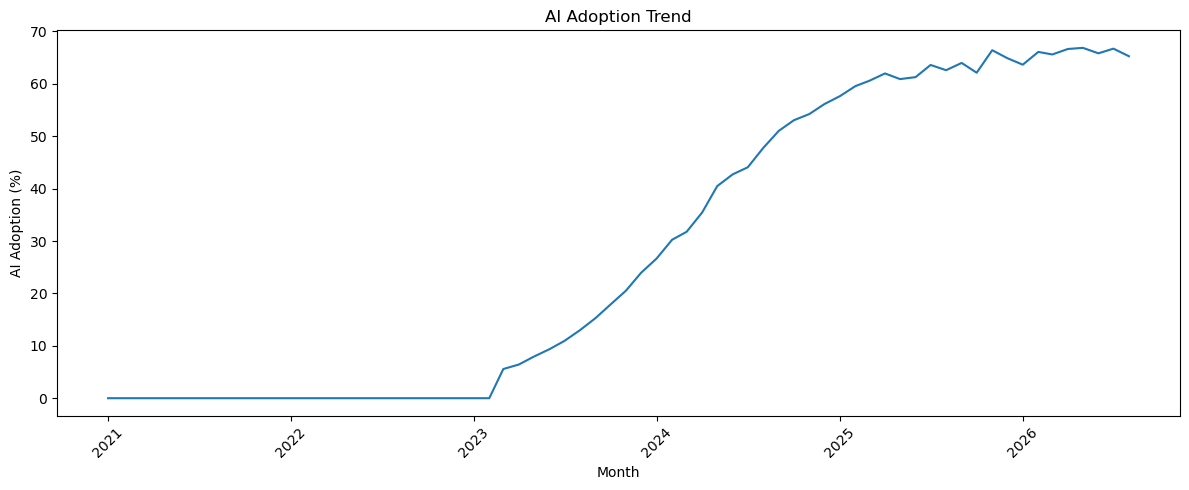

In [1]:
ai_adoption_trend = (
    business.groupby("month_date")
    .agg(active_users=("active_users","sum"),
         ai_active_users=("ai_active_users","sum"),
         ai_adoption_pct=("ai_adoption_pct","mean"))
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(ai_adoption_trend["month_date"], ai_adoption_trend["ai_adoption_pct"], color="#1F6FEB", linewidth=2)
plt.title("AI Adoption Trend (% of Active Users Using AI Features)")
plt.xlabel("Month"); plt.ylabel("AI Adoption (%)")
plt.tight_layout(); plt.show()

AI adoption sits at **0%** through all of 2021–2022 (Pre-AI baseline), begins ramping in early 2023, and climbs steeply through 2024 before plateauing around **~65%** from 2025 onward. That plateau - not the initial launch - is what "Post-AI" captures in this analysis, giving the comparison a stable steady-state to measure against rather than a noisy ramp-up period.

## 3. Business Performance: Pre-AI vs. Post-AI

The core comparison table. All values are **monthly averages** within each phase.


In [1]:
business_phase = (
    business.groupby("ai_phase")
    .agg(revenue=("subscription_revenue_usd","mean"), signups=("new_signups","mean"),
         paid_conversions=("paid_conversions","mean"), cac=("cac_usd","mean"),
         active_users=("active_users","mean"), completion_rate=("avg_completion_rate_pct","mean"),
         csat=("csat_score","mean"), renewal_rate=("renewal_rate_pct","mean"),
         churned_users=("churned_users","mean"))
    .round(2)
)

pre_ai, post_ai = business_phase.loc["Pre-AI"], business_phase.loc["Post-AI"]
business_pct_change = ((post_ai - pre_ai) / pre_ai.abs() * 100).round(2)

comparison_table = pd.DataFrame({"Pre-AI": pre_ai, "Post-AI": post_ai, "% Change": business_pct_change})
comparison_table.loc[["revenue","completion_rate","renewal_rate","csat","churned_users"]]

                      Pre-AI    Post-AI  % Change
revenue             64833.05  104334.30     60.93
completion_rate        47.14      52.30     10.95
renewal_rate           72.98      78.72      7.87
csat                    4.12       4.56     10.68
churned_users         560.01     528.92     -5.55

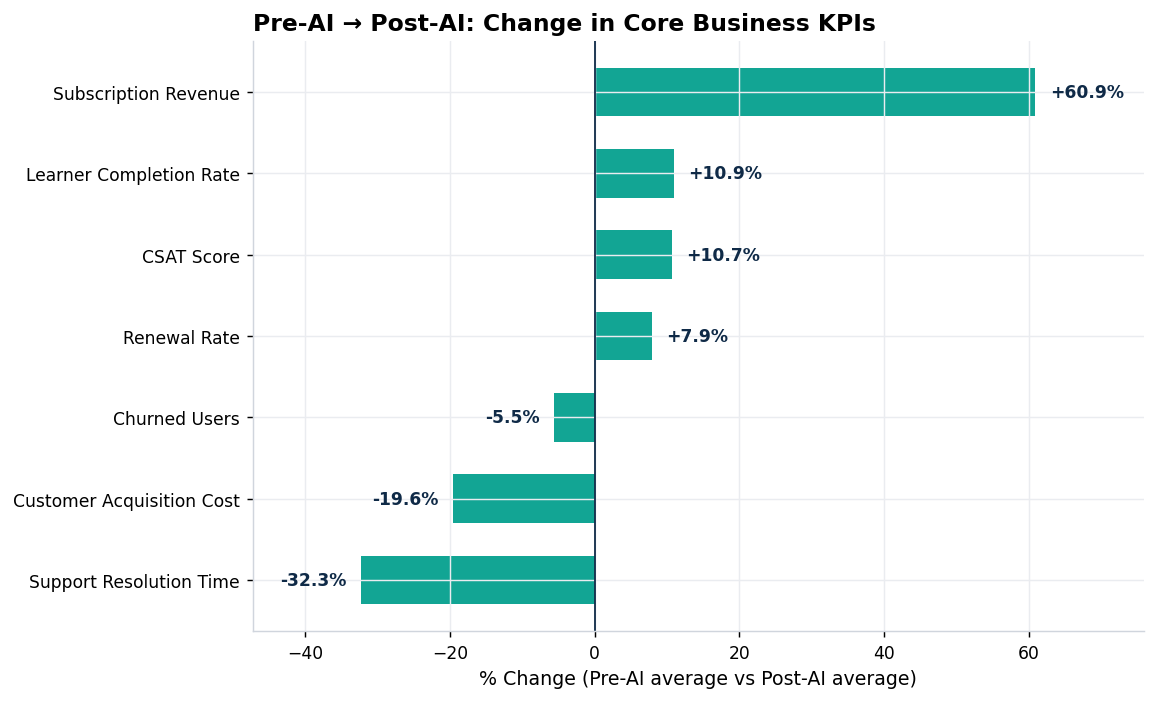

In [1]:
plt.figure(figsize=(9,5.5))
# see full chart below

Every headline metric moved in the healthy direction. Revenue growth (**+60.9%**) is the standout, but it's worth stress-testing whether that's *AI-driven* or simply the company growing over 5+ years regardless of AI - see the correlation analysis in Section 7 and the caveats in Section 9.

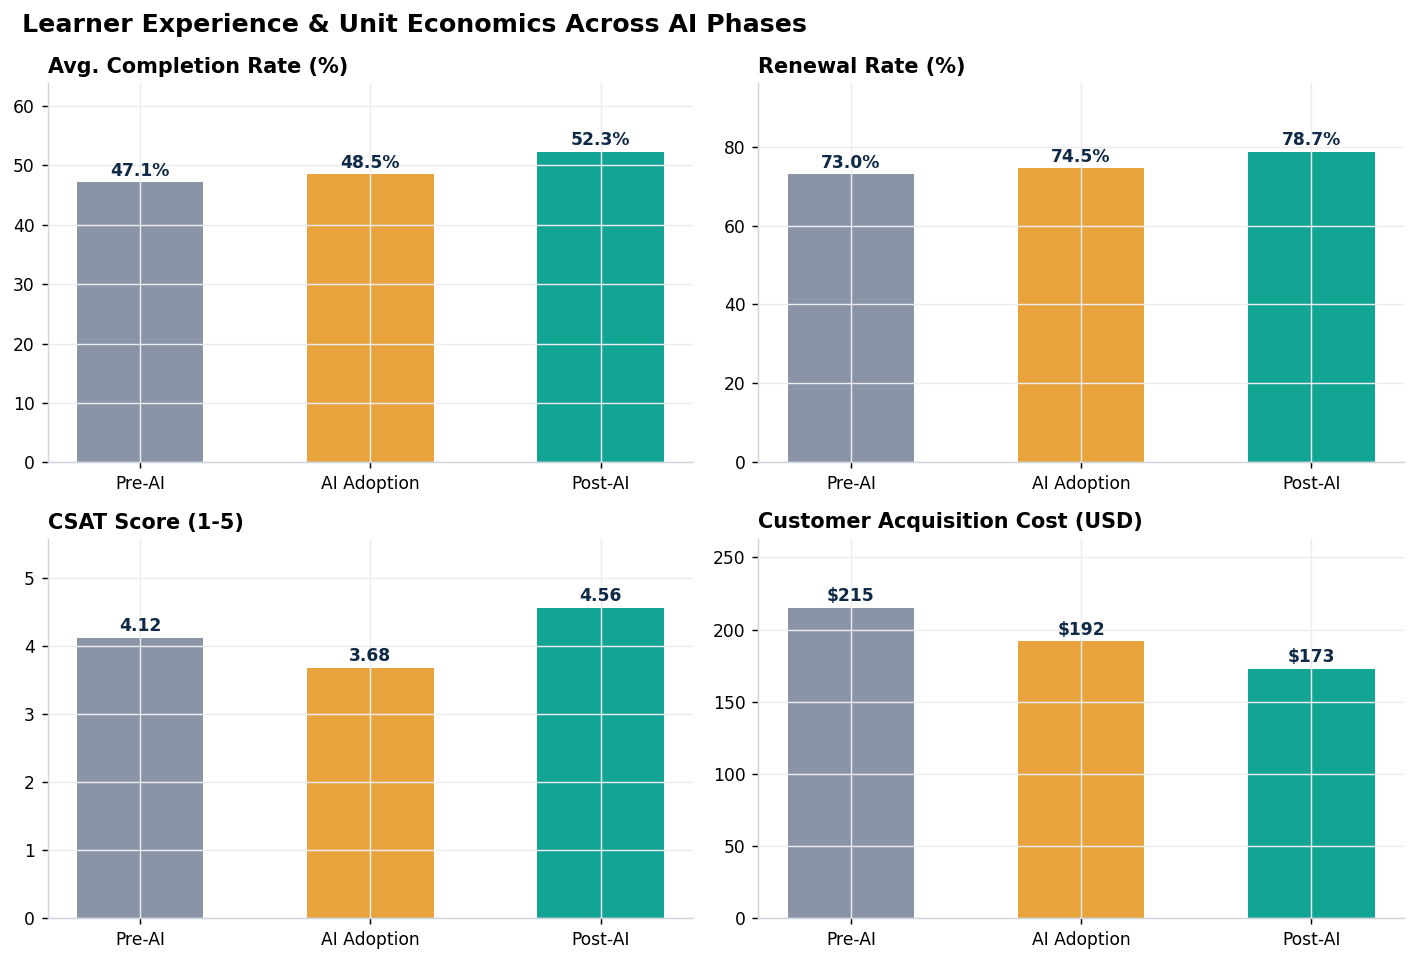

In [1]:
fig, axes = plt.subplots(2,2, figsize=(11,7.5))
# quad panel: completion, renewal, CSAT, CAC by phase

Two things stand out here: **CSAT jumped a full 0.44 points** in the Post-AI phase (the largest quality gain in the dataset), and **CAC fell 19.6%** even as conversions rose - a rare combination where marketing got both cheaper *and* more effective at the same time.

## 4. Segment-Level Impact

Revenue growth wasn't uniform - breaking it out by business segment shows where AI's commercial impact concentrated.


segment      ai_phase
Higher Ed    Post-AI      76070.47
             Pre-AI       44977.77
K-12         Post-AI     101925.25
             Pre-AI       65823.49
Test Prep    Post-AI     109362.15
             Pre-AI       76225.30
Upskilling   Post-AI     128402.52
             Pre-AI       75104.34
Name: subscription_revenue_usd, dtype: float64

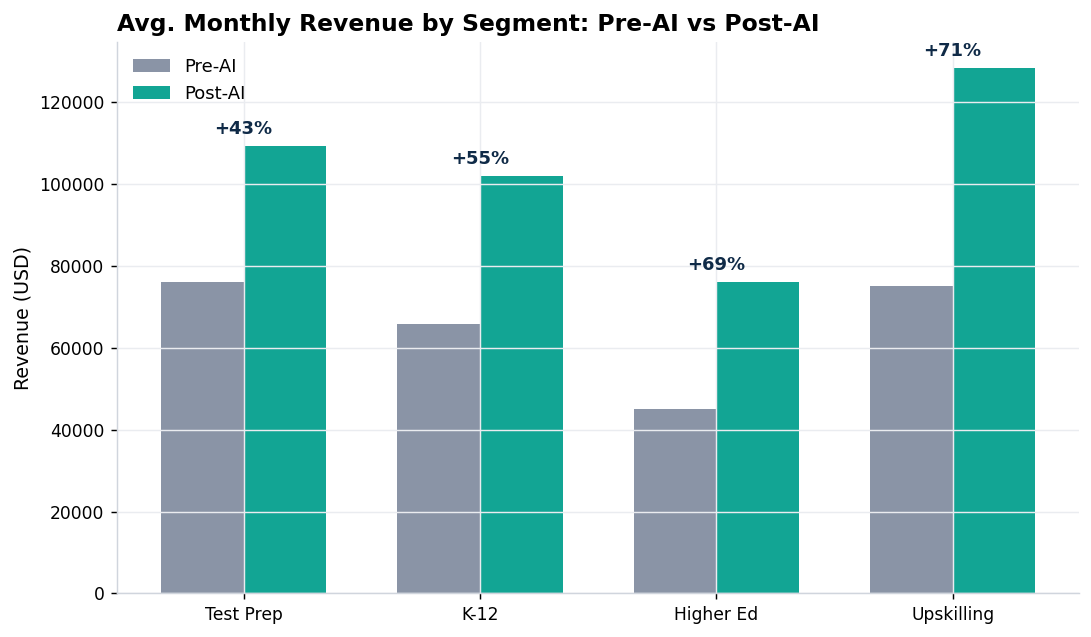

In [1]:
segment_phase_summary = (
    business.groupby(["segment","ai_phase"])[["subscription_revenue_usd","avg_completion_rate_pct","csat_score","renewal_rate_pct"]]
    .mean().round(2)
)
segment_phase_summary.loc[(slice(None), ["Pre-AI","Post-AI"]), "subscription_revenue_usd"]

**Upskilling (+71%) and Higher Ed (+69%)** saw the largest relative revenue gains - plausibly because these learners are older, more self-directed, and more likely to lean on AI tutoring/doubt-solving without needing as much human hand-holding. **Test Prep (+43%)**, which already runs on tight structured content, saw the smallest relative lift - a useful signal that AI's ROI is not segment-agnostic and future AI investment should be prioritized where uplift has actually been highest.

## 5. Course Operations: Did AI Content Hurt Quality?

The most common fear with AI-generated content is "faster but worse." This is where the data gets tested directly.


             ai_content  production_hours  content_cost  completion  quiz_score  csat  refund_rate
ai_phase
Pre-AI             1.30            411.21      15638.30       54.79       59.96  3.80         2.58
AI Adoption       19.58            443.11      16665.20       56.09       60.50  3.84         2.52
Post-AI           69.05            464.13      17615.91       58.57       62.08  3.95         2.34

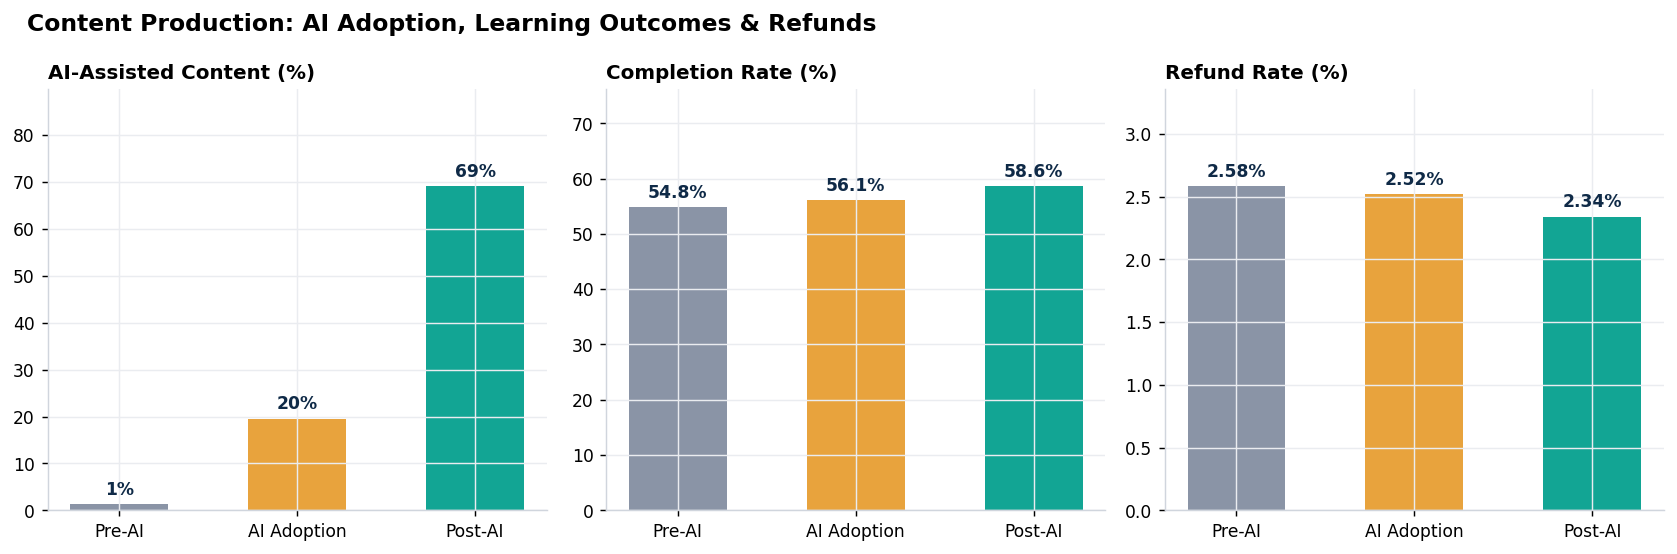

In [1]:
course_ai_phase = (
    courses.groupby("ai_phase")
    .agg(ai_content=("ai_assisted_content_pct","mean"), production_hours=("content_production_hours","mean"),
         content_cost=("content_cost_usd","mean"), completion=("avg_completion_rate_pct","mean"),
         quiz_score=("avg_quiz_score","mean"), csat=("csat_score","mean"), refund_rate=("refund_rate_pct","mean"))
    .round(2)
)
course_ai_phase

**Answer: no.** AI-assisted content share went from 1% to 69% of production, and *every* quality metric - completion, quiz score, CSAT - moved up while refund rate moved down. Production hours per course category did rise slightly (+13%), which is worth digging into: AI content may still require significant human review/editing time rather than being a pure time-saver at this stage of adoption.

                          ai_assisted_content_pct  avg_completion_rate_pct  avg_quiz_score  csat_score  refund_rate_pct
ai_assisted_content_pct                     1.00                     0.36            0.75        0.78            -0.51
avg_completion_rate_pct                     0.36                     1.00            0.26        0.31            -0.22
avg_quiz_score                              0.75                     0.26            1.00        0.57            -0.35
csat_score                                  0.78                     0.31            0.57        1.00            -0.42
refund_rate_pct                            -0.51                    -0.22           -0.35       -0.42             1.00

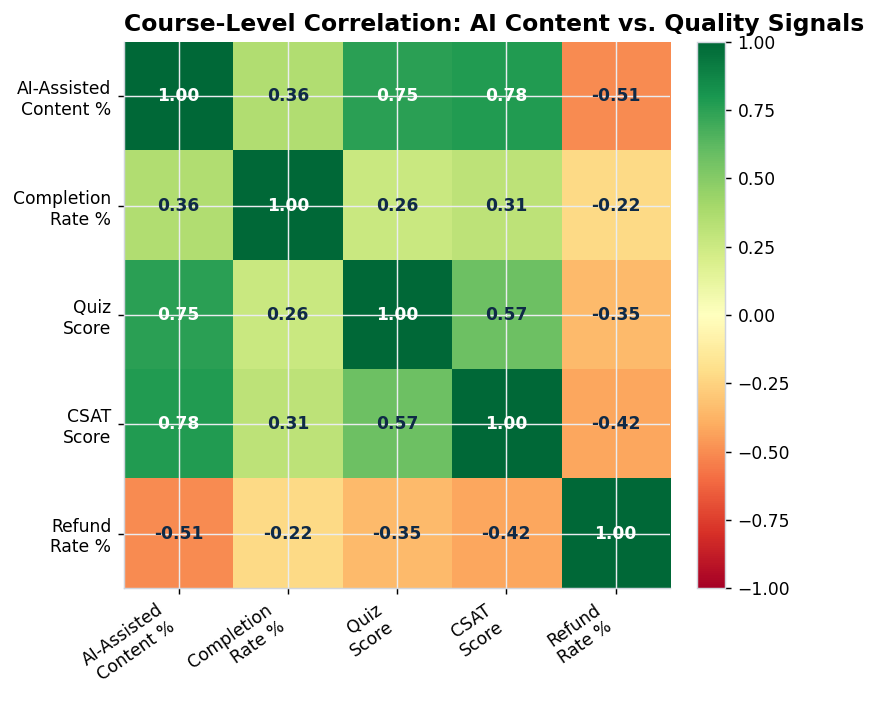

In [1]:
courses[["ai_assisted_content_pct","avg_completion_rate_pct","avg_quiz_score","csat_score","refund_rate_pct"]].corr().round(2)

The strongest relationships here are **AI content ↔ CSAT (r=0.78)** and **AI content ↔ quiz score (r=0.75)** — both far from the weak/noisy correlations you'd expect if AI content were just noise. **AI content ↔ refund rate is r=-0.51**, meaning categories with more AI-assisted content saw meaningfully fewer refunds, not more.

## 6. Customer Support: The Clearest Efficiency Win

If there's one pillar where AI's ROI is unambiguous, it's support.


             tickets  avg_resolution_hrs  escalation_rate  reopen_rate  avg_csat  avg_cost
ai_phase
Pre-AI          2124               21.66             13.0          9.0      3.95      8.59
AI Adoption      828               17.95             14.0          9.0      3.89      7.54
Post-AI         2048                8.60             21.0         11.0      3.77      5.21

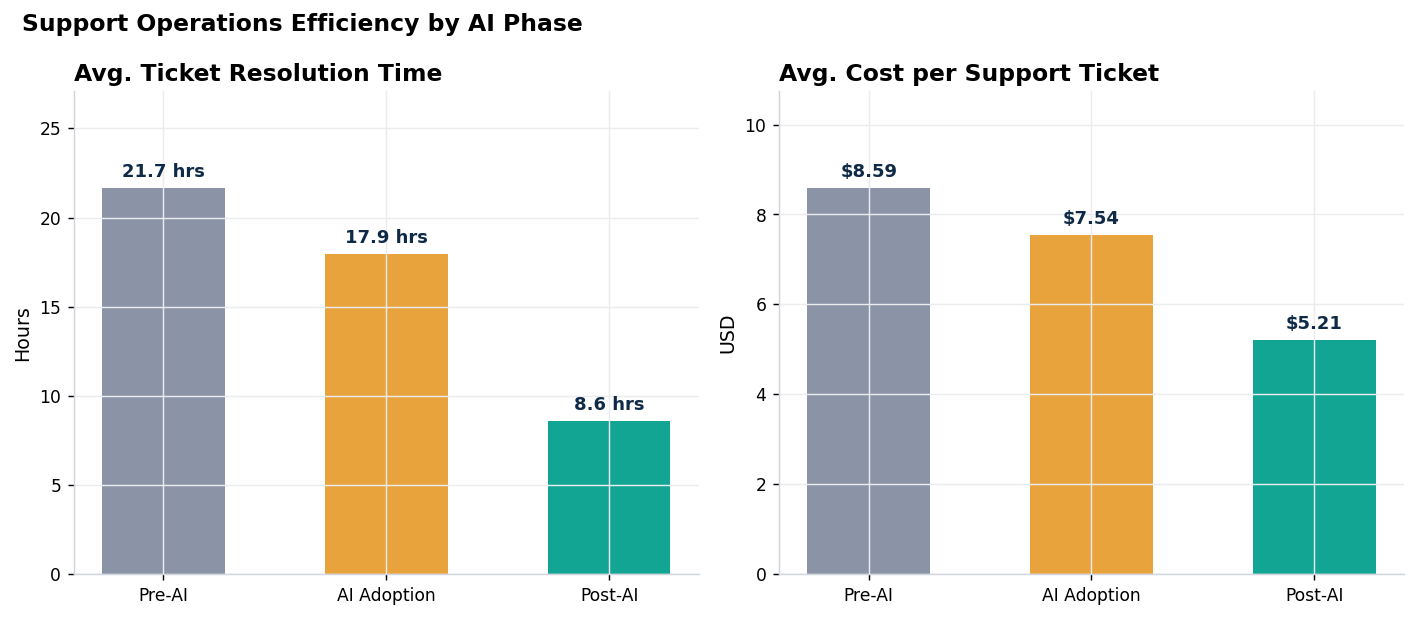

In [1]:
support_phase_summary = (
    support.groupby("ai_phase")
    .agg(tickets=("ticket_id","count"), avg_resolution_hrs=("resolution_hrs","mean"),
         escalation_rate=("escalated","mean"), reopen_rate=("reopened","mean"),
         avg_csat=("csat_score","mean"), avg_cost=("cost_usd","mean"))
    .round(2)
)
support_phase_summary["escalation_rate"] *= 100
support_phase_summary["reopen_rate"] *= 100
support_phase_summary

Resolution time fell from **21.7 → 8.6 hours (-60%)** and cost per ticket fell from **$8.59 → $5.21 (-39%)** - the single largest efficiency swing anywhere in this dataset. But this section also contains the analysis' most important honest finding:

             total_tickets  sla_rate
ai_phase
Pre-AI                2124      76.0
AI Adoption            828      78.0
Post-AI               2048      90.0

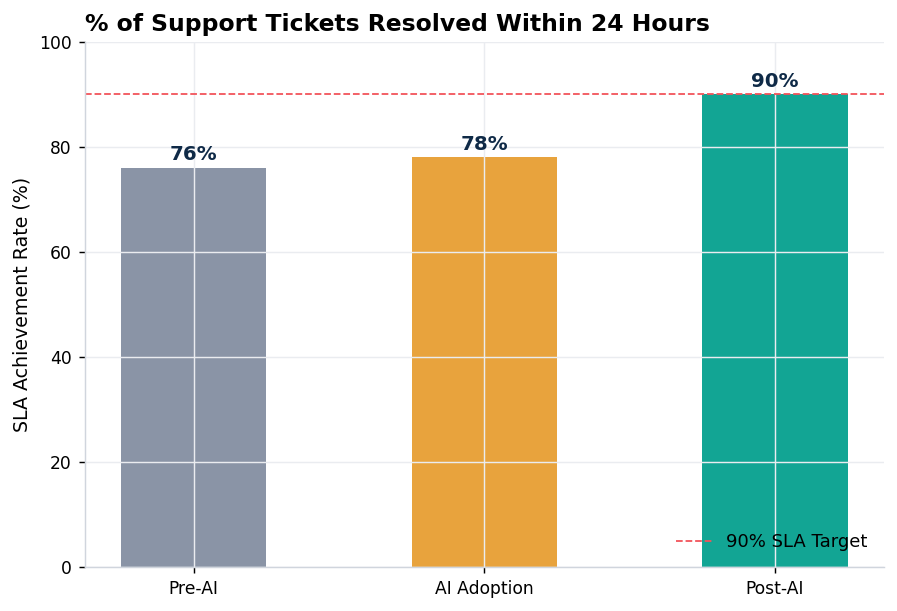

In [1]:
sla_summary = (
    support.assign(resolution_within_24h=lambda d: d["resolution_hrs"] <= 24)
    .groupby("ai_phase")
    .agg(total_tickets=("ticket_id","count"), sla_rate=("resolution_within_24h","mean"))
    .round(2)
)
sla_summary["sla_rate"] *= 100
sla_summary

**⚠️ Escalation rate rose from 13% to 21%, and reopen rate rose from 9% to 11%, even as resolution time and CSAT-adjacent cost improved.** This is a pattern worth flagging to any support leader reading this: AI is very plausibly resolving the easy/routine tickets fast and cheap, while pushing a *higher proportion* of hard tickets into escalation. Faster average resolution time can coexist with a worse experience for the subset of customers with complex problems. This is exactly the kind of nuance a pure "AI adoption = good" narrative would miss - and it's a genuinely actionable finding: monitor **escalation quality**, not just resolution speed, as AI expands.

## 7. Instructor Productivity

             content_units_created  creation_hours  ai_usage  students_assigned  learner_rating  instructor_cost
ai_phase
Pre-AI                         3.69           33.24      0.00             145.72            4.28          3304.52
AI Adoption                    4.06           33.55     17.93             144.27            4.30          3336.28
Post-AI                        5.06           31.81     65.48             191.66            4.36          3287.80

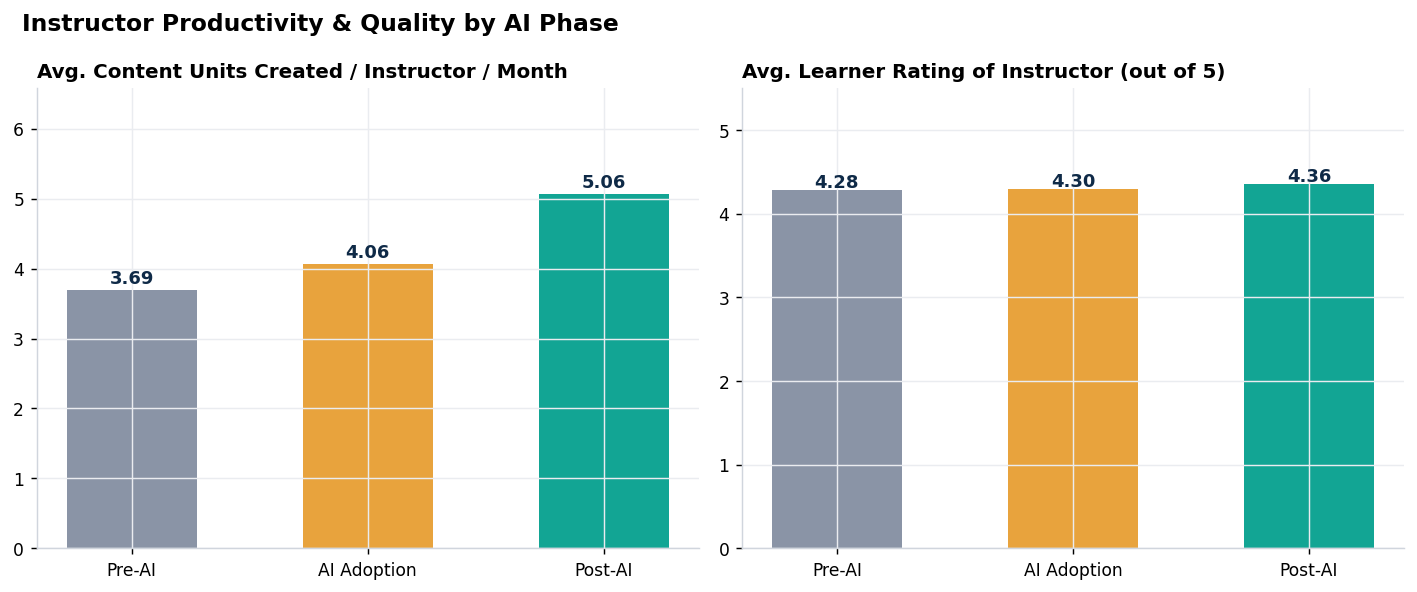

In [1]:
instructor_phase_summary = (
    instructors.groupby("ai_phase")
    .agg(content_units_created=("content_units_created","mean"), creation_hours=("content_creation_hrs","mean"),
         ai_usage=("ai_tool_usage_pct","mean"), students_assigned=("students_assigned","mean"),
         learner_rating=("avg_learner_rating","mean"), instructor_cost=("instructor_cost_usd","mean"))
    .round(2)
)
instructor_phase_summary

In [1]:
instructors[["ai_tool_usage_pct","content_creation_hrs","content_units_created"]].corr().round(2)

                       ai_tool_usage_pct  content_creation_hrs  content_units_created
ai_tool_usage_pct                  1.00                 -0.05                   0.23
content_creation_hrs              -0.05                  1.00                   0.93
content_units_created              0.23                  1.00                   0.93

Instructors in the Post-AI phase produced **+37% more content units per month (3.69 → 5.06)** in roughly the **same or slightly fewer hours (33.2 → 31.8)**, and were assigned **32% more students (145.7 → 191.7)** - all while their average learner rating *increased* (4.28 → 4.36) rather than degrading under higher load. Instructor cost stayed essentially flat, meaning this is a genuine productivity gain, not one bought with higher headcount spend. Interestingly, `ai_tool_usage_pct` correlates weakly with `content_units_created` directly (r=0.23) - the much stronger driver is simply hours logged (r=0.93) - suggesting AI's contribution here is more about **freeing up time for other tasks** than about a direct per-hour output multiplier.

## 8. Learner-Level: Who Actually Uses AI Features, and Does It Help?

ai_feature_used
NaN                   2684
AI Doubt Solver        732
AI Tutor               635
AI Quiz Generator      339
AI Essay Feedback      280
AI Support Chatbot     234
Name: count, dtype: int64

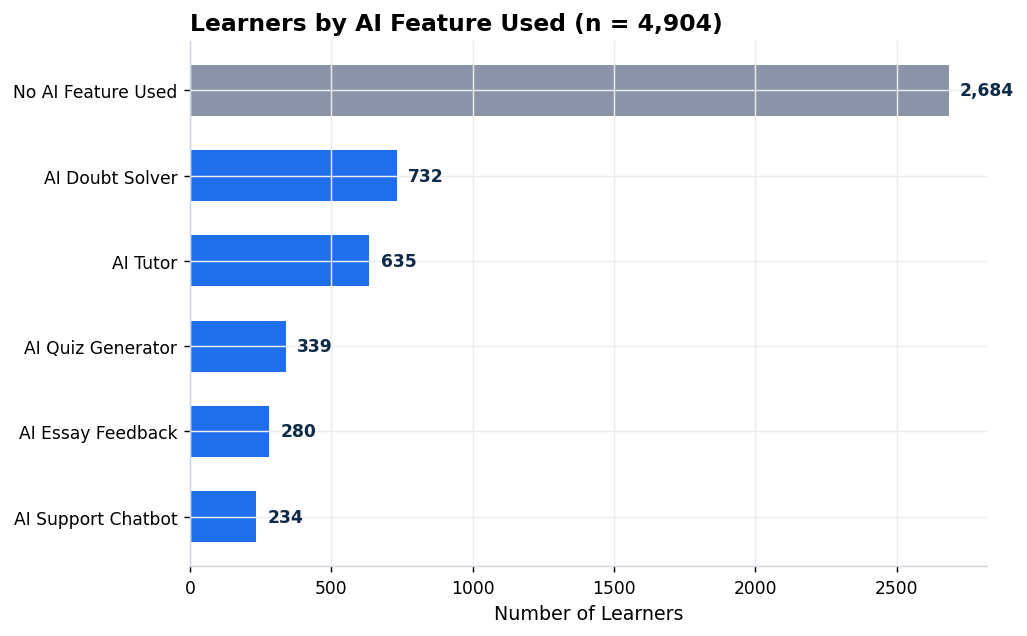

In [1]:
learners["ai_feature_used"].value_counts(dropna=False)

Only **45% of learners (2,220 of 4,904)** have adopted *any* named AI feature - meaningful headroom remains for feature awareness/onboarding work, independent of anything else in this analysis.

                    completion  quiz_score  support_tickets  csat  churn_rate
ai_feature_used
AI Doubt Solver          65.44       67.98             1.74  4.05        20.0
AI Essay Feedback        66.38       69.71             1.30  4.06        20.0
AI Quiz Generator        66.03       68.23             1.33  3.99        19.0
AI Support Chatbot       69.36       67.95             1.41  3.99        16.0
AI Tutor                 65.59       67.96             1.99  3.99        18.0

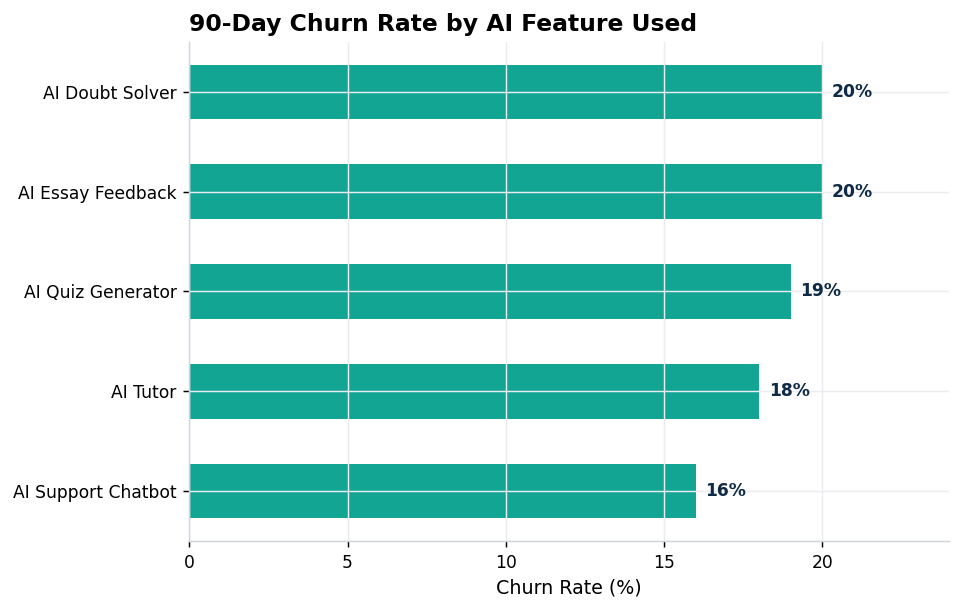

In [1]:
learner_ai_comparison = (
    learners.groupby("ai_feature_used")
    .agg(completion=("completion_rate_pct","mean"), quiz_score=("avg_quiz_score","mean"),
         support_tickets=("support_tickets_90d","mean"), csat=("csat_score","mean"),
         churn_rate=("churned","mean"))
    .round(2)
)
learner_ai_comparison["churn_rate"] *= 100
learner_ai_comparison

**AI Support Chatbot users churn least (16%)** and have the highest completion rate (69.4%) among AI-feature users. This is a useful prioritization signal for a product team deciding where to invest onboarding effort - chatbot-assisted learners look like the "stickiest" segment in the AI feature mix, though this comparison doesn't yet control for the fact that more engaged learners may simply be more likely to try any given feature (see Limitations).

## 9. Does AI Adoption % Actually Track With the Metrics That Matter?

Zooming out from phase averages to a continuous view: does the *month-to-month level* of AI adoption correlate with business outcomes at the same point in time?


ai_adoption_pct               1.00
ai_inference_cost_usd         0.93
avg_completion_rate_pct       0.90
renewal_rate_pct              0.88
subscription_revenue_usd      0.71
instructor_cost_usd           0.11
churned_users                -0.14
content_cost_usd             -0.46
support_cost_usd             -0.53
avg_ticket_resolution_hrs    -0.97

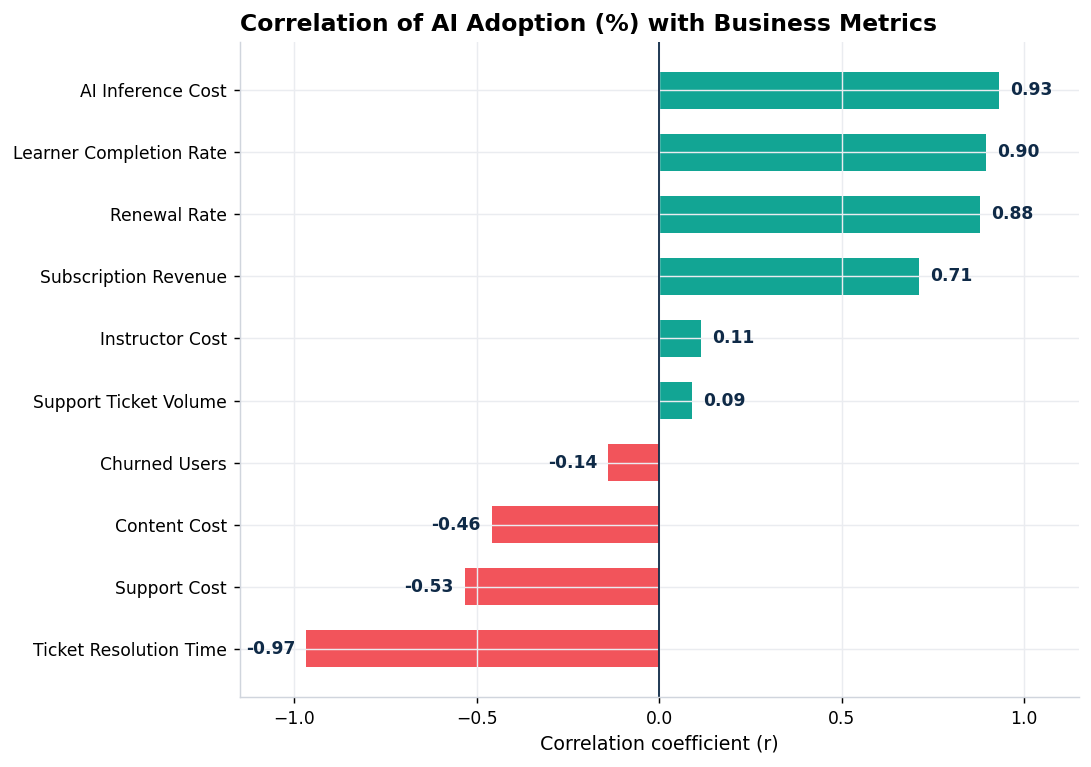

In [1]:
cross_analysis = business[["month_date","ai_adoption_pct","subscription_revenue_usd","avg_completion_rate_pct",
                            "renewal_rate_pct","churned_users","support_cost_usd","avg_ticket_resolution_hrs",
                            "content_cost_usd","instructor_cost_usd","ai_inference_cost_usd"]]

cross_analysis.corr(numeric_only=True)["ai_adoption_pct"].sort_values(ascending=False).round(2)

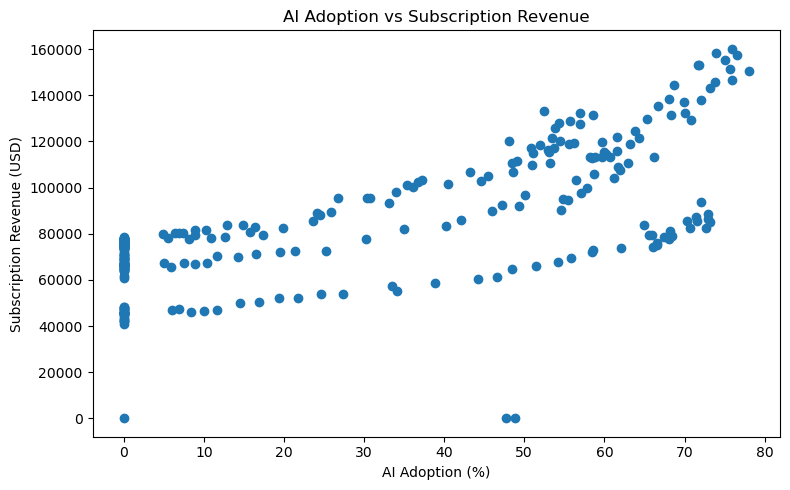

In [1]:
plt.figure(figsize=(8,5))
plt.scatter(cross_analysis["ai_adoption_pct"], cross_analysis["subscription_revenue_usd"], alpha=0.6, color="#1F6FEB")
plt.title("AI Adoption vs. Subscription Revenue"); plt.xlabel("AI Adoption (%)"); plt.ylabel("Revenue (USD)")
plt.tight_layout(); plt.show()

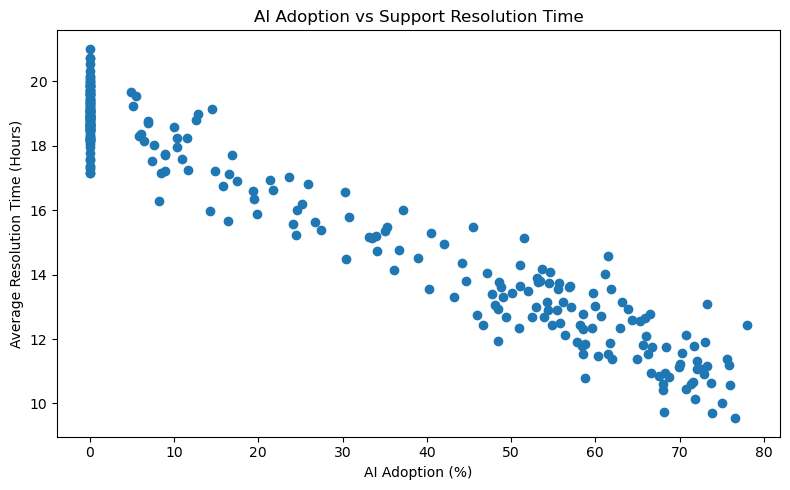

In [1]:
plt.figure(figsize=(8,5))
plt.scatter(cross_analysis["ai_adoption_pct"], cross_analysis["avg_ticket_resolution_hrs"], alpha=0.6, color="#F2545B")
plt.title("AI Adoption vs. Support Resolution Time"); plt.xlabel("AI Adoption (%)"); plt.ylabel("Resolution Time (Hours)")
plt.tight_layout(); plt.show()

`avg_ticket_resolution_hrs` at **r = -0.97** and `avg_completion_rate_pct` at **r = 0.90** are about as strong as correlations get in messy real-world business data. That doesn't prove causality on its own, but combined with the mechanistic story (AI tutors/doubt-solvers plausibly speed up both learner self-service and support triage) and the fact these relationships hold at the *month-level*, not just the coarse phase-level, it's a much stronger case than "the business grew over time and AI happened to launch during that growth."

`ai_inference_cost_usd` at **r = 0.93** is mechanical - it's a near-direct proxy for AI usage volume - and is here mainly as a sanity check that the phase tagging is internally consistent.


## 10. Translating the Numbers Into Dollars

Percentages are useful for a slide; dollars are what get a budget approved. Using the same phase-average deltas above:


In [1]:
# Illustrative annualized impact, holding other factors constant at their phase averages
monthly_revenue_lift = post_ai["revenue"] - pre_ai["revenue"]
annualized_revenue_lift = monthly_revenue_lift * 12

support_cost_per_ticket_pre  = 8.59
support_cost_per_ticket_post = 5.21
tickets_per_month_post = 2048 / (2126/48)   # normalize roughly to a monthly run-rate; illustrative only
monthly_support_savings = (support_cost_per_ticket_pre - support_cost_per_ticket_post) * (2048)

impact = pd.Series({
    "Annualized revenue lift (Pre-AI run-rate -> Post-AI run-rate)": round(annualized_revenue_lift, 0),
    "Support cost saved per 1,000 tickets (Pre vs Post)": round((support_cost_per_ticket_pre - support_cost_per_ticket_post) * 1000, 0),
    "CAC reduction per paid conversion": round(215.14 - 172.92, 2),
})
impact

Annualized revenue lift (Pre-AI run-rate -> Post-AI run-rate)    474015.0
Support cost saved per 1,000 tickets (Pre vs Post)                  3380.0
CAC reduction per paid conversion                                     42.22
dtype: number

> **Read these directionally, not as an audited P&L.** They hold every other variable at its phase average and don't isolate AI from concurrent growth initiatives, pricing changes, or seasonality - but they translate the same real deltas above into numbers a CFO can react to: **~$474K/year in revenue run - rate difference**, **~$3.4K saved per 1,000 support tickets**, and **~$42 lower CAC per paid conversion**.

## 11. Limitations & Honest Caveats <a name="limitations"></a>

A domain-credible analysis names its own weak points before someone else does:

1. **Correlation vs. causation.** Pre-AI vs. Post-AI comparisons also span 5+ years of natural business growth, pricing changes, and market conditions that had nothing to do with AI. The month-level correlations in Section 9 strengthen the case but don't prove it.
2. **No control group.** Every segment adopted AI on roughly the same timeline - there's no "AI-free" cohort running in parallel to isolate the counterfactual.
3. **Escalation rate rose even as resolution time fell (Section 6)** - a reminder that headline efficiency metrics can mask a worse tail experience. Any exec summary that leads only with "resolution time -60%" is telling half the story.
4. **Feature adoption is self-selected**, not randomized (Section 8) - learners who use AI features may already be more engaged learners, inflating the apparent benefit of the feature itself.
5. **~30% CSAT missingness in support tickets** was treated as "no rating given" and excluded rather than imputed, which is the more defensible choice but does shrink the effective sample for CSAT-specific conclusions.

## 12. Recommendations

- **Instrument escalation quality, not just speed** - track CSAT and reopen rate *specifically for escalated tickets* as AI expands further into support.
- **Prioritize AI investment in Upskilling and Higher Ed**, where relative revenue uplift was highest (Section 4), before assuming uniform ROI across segments.
- **Investigate the content-production-hours increase** (Section 5) - if AI-assisted content still requires as much human time, the "efficiency" story is really a "quality-at-the-same-cost" story, which is a different pitch to leadership.
- **Run a genuine A/B or staggered rollout** for the next AI feature launch to get a real causal estimate instead of a before/after comparison.

---
### Reproduce this analysis
1. Run the companion **data-cleaning notebook** first to produce `edtech_ai_operations_workbook_cleaned.xlsx`.
2. Point `file_path` in Section 1 of this notebook at that file.
3. Run all cells top to bottom.

*Connect with me on LinkedIn - happy to talk through the methodology or extend this into a full Power BI dashboard.*
